# Entregable Final 2: Agrupación con K-Means
En este entorno resolvemos el ejercicio de clustering utilizando el algoritmo de aprendizaje no supervisado **K-Means**, empleando de nuevo el clásico dataset de Iris para evaluar cómo el modelo agrupa estadísticamente las plantas sin conocer sus nombres biológicos previamente.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import contingency_matrix
import numpy as np

### 1 & 2. Cargar y Estandarizar el dataset
Cargamos `iris`, ignorando en principio las etiquetas `y` para el entreno, ya que K-Means es un algoritmo exploratorio *No Supervisado*. Estandarizamos fuertemente las escalas de las variables usando `StandardScaler`.

In [ ]:
# ------------------------------------------------------------
# 1) Cargar dataset real: Iris (3 clases reales, sin usar etiquetas para entrenar)
# ------------------------------------------------------------

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["target_name"] = df["target"].map(lambda i: iris.target_names[i])

display(df.head())

1) Dataset real: Iris (clustering NO supervisado)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
print("N muestras:", df.shape[0], "| N variables:", len(iris.feature_names))
print("Clases reales (solo para comparar al final):", iris.target_names)
X = df[iris.feature_names].values
y_true = df["target"].values

N muestras: 150 | N variables: 4
Clases reales (solo para comparar al final): ['setosa' 'versicolor' 'virginica']


In [4]:
# ------------------------------------------------------------
# 2) Exploración rápida: estadísticas + 2 variables (scatter) para hacerse idea
# ------------------------------------------------------------
print("2) Exploración rápida")

display(df[iris.feature_names].describe().T[["mean","std","min","max"]].head(8))

2) Exploración rápida


,mean,std,min,max
sepal length (cm),5.843333,0.828066,4.3,7.9
sepal width (cm),3.057333,0.435866,2.0,4.4
petal length (cm),3.758000,1.765298,1.0,6.9
petal width (cm),1.199333,0.762238,0.1,2.5


In [5]:
X = iris.data
target_names = iris.target_names

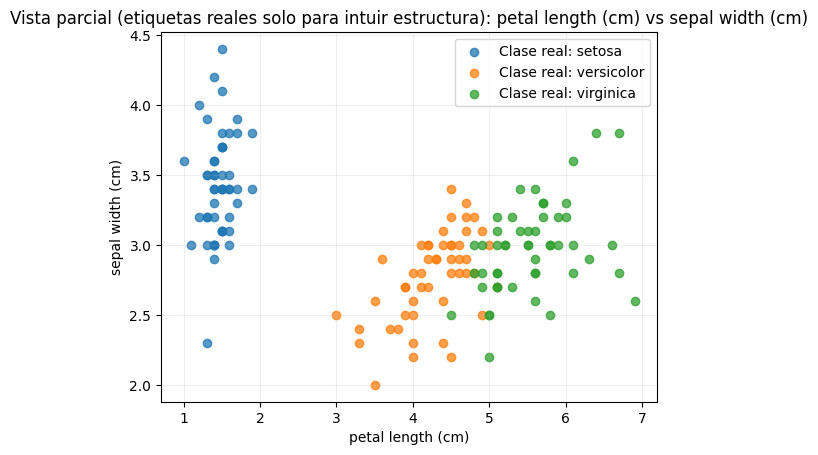

In [6]:
pair = ("petal length (cm)", "sepal width (cm)")
plt.figure()
for c in np.unique(y_true):
    mask = y_true == c
    plt.scatter(df.loc[mask, pair[0]], df.loc[mask, pair[1]], alpha=0.75, label=f"Clase real: {iris.target_names[c]}")
plt.title(f"Vista parcial (etiquetas reales solo para intuir estructura): {pair[0]} vs {pair[1]}")
plt.xlabel(pair[0]); plt.ylabel(pair[1])
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [7]:
# 2. Estandarizar las variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Tamaño del dataset:", X_scaled.shape)

Tamaño del dataset: (150, 4)


### 3. Entrenar el modelo KMeans
Ya sabemos que el número de clusters es 3 en el dataset de Iris pero de todos modos, aplicaremos el método del codo para confirmarlo

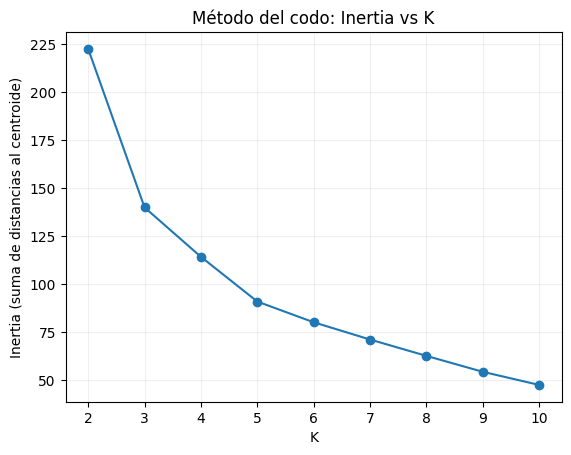

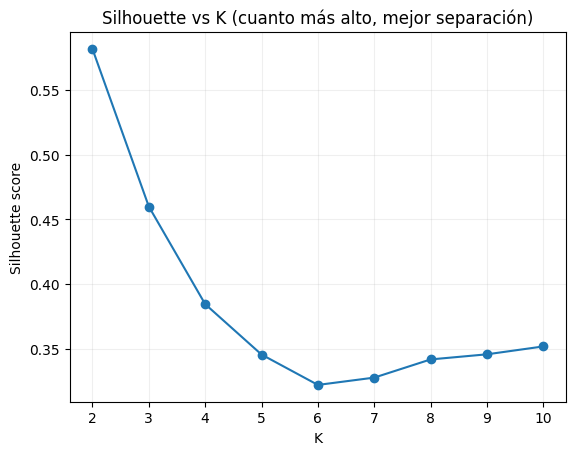

In [ ]:
from sklearn.metrics import silhouette_score

# 3) K-means: probar con varios K (2-10), evaluar con inertia y silhouette score, elegir el mejor K
# con el método del codo (inertia) y silhouette score (cuanto más alto, mejor separación entre clusters)
ks = range(2, 11)
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.title("Método del codo: Inertia vs K")
plt.xlabel("K")
plt.ylabel("Inertia (suma de distancias al centroide)")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure()
plt.plot(list(ks), sil_scores, marker="o")
plt.title("Silhouette vs K (cuanto más alto, mejor separación)")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# Elegimos K=3 por el codo y silhouette score
K=3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit_predict(X_scaled)
clusters_pred = kmeans.labels_

### 4. Representación Gráfica Comparativa y PCA
Dado que los datos de las flores poseen **4 características biológicas** (4 dimensiones métricas de pétalos y sépalos), el ojo humano no puede percibir el clusterizado tridimensional de forma efectiva. 

Para ello empleamos la técnica matemática de **Análisis de Componentes Principales (PCA)** que resume las dimensiones y comprime las características de 4D a un plano 2D, capturando la máxima varianza de información.

Visualización clusters (PCA 2D) + centroides


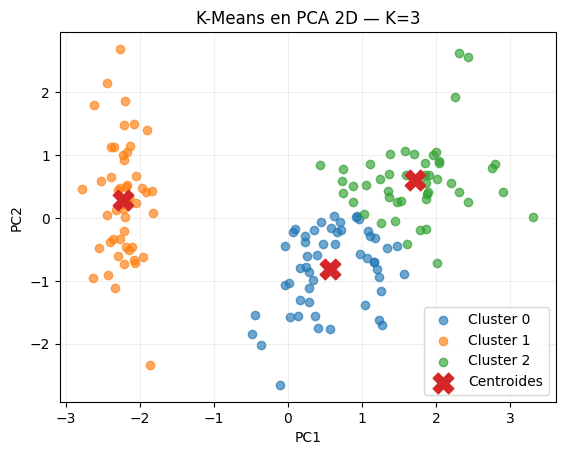

In [ ]:
print("Visualización clusters (PCA 2D) + centroides")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

centroids_s = kmeans.cluster_centers_              # centroides en espacio estandarizado (D real)
centroids_pca = pca.transform(centroids_s)         # proyectarlos al plano PCA 2D

plt.figure()
for c in range(K):
    mask = clusters_pred == c
    plt.scatter(X_pca[mask,0], X_pca[mask,1], alpha=0.65, label=f"Cluster {c}")
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=220, marker="X", label="Centroides")
plt.title(f"K-Means en PCA 2D — K={K}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

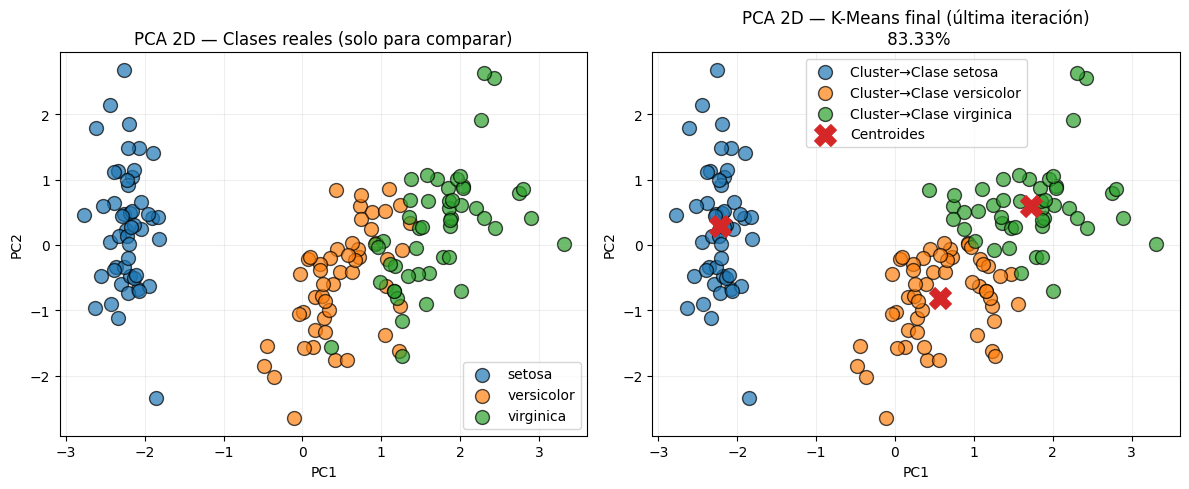

In [11]:
final_labels2d = clusters_pred
final_centroids2d = centroids_pca
try:
    from scipy.optimize import linear_sum_assignment
    K = len(np.unique(final_labels2d))
    contingency = np.zeros((len(np.unique(y_true)), K), dtype=int)
    for i in range(len(y_true)):
        contingency[y_true[i], final_labels2d[i]] += 1
    cost = contingency.max() - contingency
    row_ind, col_ind = linear_sum_assignment(cost)

    mapping = {col: row for row, col in zip(row_ind, col_ind)}  # cluster -> clase real
    aligned_labels2d = np.array([mapping[c] for c in final_labels2d])

except Exception:
    K = len(np.unique(final_labels2d))
    contingency = np.zeros((len(np.unique(y_true)), K), dtype=int)
    for i in range(len(y_true)):
        contingency[y_true[i], final_labels2d[i]] += 1
    mapping = {c: np.argmax(contingency[:, c]) for c in range(K)}
    aligned_labels2d = np.array([mapping[c] for c in final_labels2d])
agreement = (aligned_labels2d == y_true).mean()
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for c in np.unique(y_true):
    mask = y_true == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.7, label=iris.target_names[c], s=100, edgecolor='k')
plt.title("PCA 2D — Clases reales (solo para comparar)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.2)
plt.subplot(1, 2, 2)
for c in np.unique(aligned_labels2d):
    mask = aligned_labels2d == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.7, label=f"Cluster-->Clase {iris.target_names[c]}", s=100, edgecolor='k')
plt.scatter(final_centroids2d[:, 0], final_centroids2d[:, 1], s=240, marker="X", label="Centroides")
plt.title(f"PCA 2D — K-Means final (última iteración)\n {agreement:.2%}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

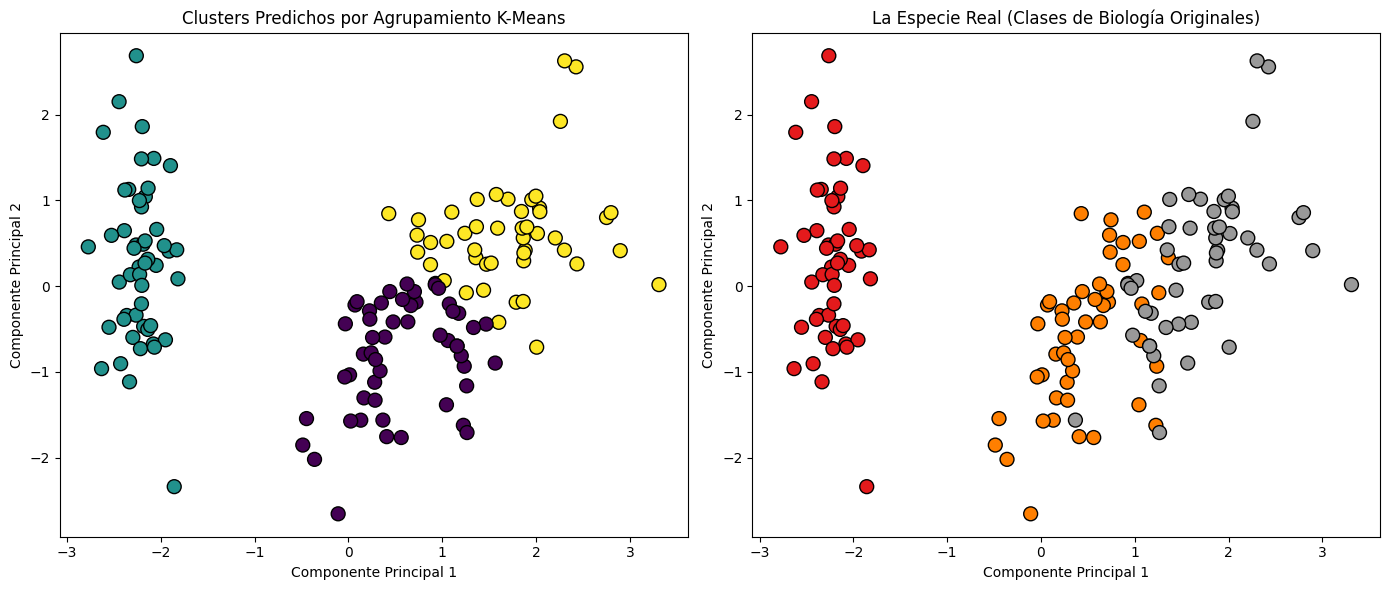

In [12]:
# Resumimos las variables reduciendo a 2 componentes (ejes X e Y)
y_real = iris.target  # Usaremos las etiquetas para comparar visualmente

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 6))

# Gráfico 1: Clusters inventados/descubiertos geométricamente por K-Means
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pred, cmap='viridis', s=100, edgecolor='k')
plt.title('Clusters Predichos por Agrupamiento K-Means')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Gráfico 2: La naturaleza real de las especies de flores
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_real, cmap='Set1', s=100, edgecolor='k')
plt.title('La Especie Real (Clases de Biología Originales)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

### 5. Análisis de Resultados, Conclusión y Comparativas

**Análisis Visual**: 
- Al entrenar el modelo K-Means con K=3 y representarlo en 2D, observamos la formación exitosa y contundente de tres clústeres matemáticos de colores distintos.
- Uno de esos clústeres (que corresponde originalmente a la especie única de *Iris Setosa*) está drásticamente apartado geométricamente hablando. Es un clúster puro, sin mezclar, siendo identificado de la nada mediante el algoritmo al percibir cuán distintas son estadísticamente.
- Los otros dos clústeres geográficos (que vendrían a ser *Versicolor y Virginica*) en cambio se perciben con una leve superposición. K-Means intenta trazar una fuerte barrera recta en la separación al minimizar la varianza de las distancias internas, con el percance de que varias flores limítrofes acaban agrupándose obligatoriamente en el otro cluster, a espaldas de su especie real.
- Esta pequeña discrepancia nos certifica que KMeans evalúa únicamente por distancias euclidianas, y es ajeno por defecto a las variables orgánicas reales complejas.

**Diferencias Principales con KNN**:
- **KNN** (evaluado en el ejercicio anterior) es netamente **Supervisado**. Se diseña bajo el uso de la variable objetivo o etiquetas `y`. Las fronteras perimetrales de cada caso se trazan conociendo al maestro o al vecino contiguo y asignando clases basadas en las familias biológicas.
- **K-Means**, por otra parte, es netamente **No Supervisado**. En sus capas internas no se alimenta nunca con las etiquetas de las clases de flores. Recibe los números matemáticos huecos de las hojas o los tallos y su único propósito geológico es establecer los "K Centroides", aglomerando puntos en torno a los epicentros y simulando un clúster abstracto mediante puras distancias. Descubre patrones ocultos, pero no predice con seguridad las especies ya tabuladas empíricamente por los humanos.